In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess

BASE = '/content/drive/MyDrive/STEW_dataset'

!apt-get install -y mdbtools -q

result = subprocess.run(['mdb-tables', f'{BASE}/dataset'], capture_output=True, text=True)
print("Tables in dataset:", result.stdout)

result2 = subprocess.run(['mdb-tables', f'{BASE}/class_012'], capture_output=True, text=True)
print("Tables in class_012:", result2.stdout)

result3 = subprocess.run(['mdb-tables', f'{BASE}/rating'], capture_output=True, text=True)
print("Tables in rating:", result3.stdout)

result4 = subprocess.run(['mdb-tables', f'{BASE}/three_class_one_hot'], capture_output=True, text=True)
print("Tables in three_class_one_hot:", result4.stdout)

Mounted at /content/drive
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libmdb3 libmdbsql3
Suggested packages:
  bash-completion
The following NEW packages will be installed:
  libmdb3 libmdbsql3 mdbtools
0 upgraded, 3 newly installed, 0 to remove and 1 not upgraded.
Need to get 136 kB of archives.
After this operation, 486 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libmdb3 amd64 1.0.0+dfsg-1 [68.9 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libmdbsql3 amd64 1.0.0+dfsg-1 [18.8 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 mdbtools amd64 1.0.0+dfsg-1 [48.3 kB]
Fetched 136 kB in 1s (92.4 kB/s)
Selecting previously unselected package libmdb3:amd64.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../libmdb3_1.0.0+dfsg-1_amd64.deb ...
Unpacking libmdb3:amd64 (1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if 'STEW' in f or 'stew' in f or 'sub' in f:
            print(os.path.join(root, f))
    for d in dirs:
        if 'STEW' in d or 'stew' in d:
            print(os.path.join(root, d))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ishita_submission.zip
/content/drive/MyDrive/STEW_dataset.zip
/content/drive/MyDrive/Colab Notebooks/Copy of Group5 final submission


In [ ]:
import zipfile
import os

with zipfile.ZipFile('/content/drive/MyDrive/STEW_dataset.zip', 'r') as z:
    z.extractall('/content/STEW_dataset')

for f in os.listdir('/content/STEW_dataset'):
    print(f)

dataset.mat
class_012.mat
EEG data summary.pdf
three_class_one_hot.mat
rating.mat


In [ ]:
import scipy.io as sio

dataset = sio.loadmat('/content/STEW_dataset/dataset.mat')
print("dataset keys:", list(dataset.keys()))

labels = sio.loadmat('/content/STEW_dataset/class_012.mat')
print("class_012 keys:", list(labels.keys()))

rating = sio.loadmat('/content/STEW_dataset/rating.mat')
print("rating keys:", list(rating.keys()))

for key in dataset.keys():
    if not key.startswith('_'):
        print(f"dataset['{key}'] shape:", dataset[key].shape)

for key in labels.keys():
    if not key.startswith('_'):
        print(f"class_012['{key}'] shape:", labels[key].shape)

dataset keys: ['__header__', '__version__', '__globals__', 'dataset']
class_012 keys: ['__header__', '__version__', '__globals__', 'class_012']
rating keys: ['__header__', '__version__', '__globals__', 'rating']
dataset['dataset'] shape: (14, 19200, 45)
class_012['class_012'] shape: (45, 1)


In [ ]:
import scipy.io as sio
import numpy as np
from scipy.signal import butter, filtfilt, welch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

dataset = sio.loadmat('/content/STEW_dataset/dataset.mat')['dataset']
labels_raw = sio.loadmat('/content/STEW_dataset/class_012.mat')['class_012'].flatten()
rating = sio.loadmat('/content/STEW_dataset/rating.mat')['rating'].flatten()

print(f"EEG data shape: {dataset.shape}")
print(f"Labels shape: {labels_raw.shape}")
print(f"Unique labels: {np.unique(labels_raw)}")
print(f"Label distribution: {dict(zip(*np.unique(labels_raw, return_counts=True)))}")
print(f"Rating range: {rating.min()} to {rating.max()}")

EEG data shape: (14, 19200, 45)
Labels shape: (45,)
Unique labels: [0 1 2]
Label distribution: {np.uint8(0): np.int64(13), np.uint8(1): np.int64(18), np.uint8(2): np.int64(14)}
Rating range: 4 to 9


In [ ]:
CHANNELS = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
FS = 128
EPOCH_LEN = 256
OVERLAP = 128

def highpass_filter(data, cutoff=0.5, fs=128, order=4):
    nyq = fs / 2
    b, a = butter(order, cutoff/nyq, btype='high')
    return filtfilt(b, a, data, axis=1)

def artifact_reject(epoch, threshold=100):
    return np.all(np.abs(epoch) < threshold)

def extract_band_power(epoch, fs=128):
    freqs_bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta':  (13, 30),
        'gamma': (30, 45)
    }
    features = []
    for ch in range(epoch.shape[0]):
        freqs, psd = welch(epoch[ch], fs=fs, nperseg=fs)
        for band, (lo, hi) in freqs_bands.items():
            idx = np.where((freqs >= lo) & (freqs <= hi))[0]
            features.append(np.mean(psd[idx]))
    return np.array(features)

def frontal_theta_parietal_alpha(epoch, fs=128):
    frontal_chs = [CHANNELS.index(c) for c in ['AF3','F7','F3','F4','F8']]
    parietal_chs = [CHANNELS.index(c) for c in ['P7','P8']]

    theta_powers, alpha_powers = [], []
    for ch in frontal_chs:
        freqs, psd = welch(epoch[ch], fs=fs, nperseg=fs)
        theta_idx = np.where((freqs >= 4) & (freqs < 8))[0]
        theta_powers.append(np.mean(psd[theta_idx]))
    for ch in parietal_chs:
        freqs, psd = welch(epoch[ch], fs=fs, nperseg=fs)
        alpha_idx = np.where((freqs >= 8) & (freqs < 13))[0]
        alpha_powers.append(np.mean(psd[alpha_idx]))

    ft = np.mean(theta_powers)
    pa = np.mean(alpha_powers)
    ratio = ft / (pa + 1e-8)
    return np.array([ft, pa, ratio])

def inter_channel_coherence(epoch, fs=128):
    coherences = []
    alpha_lo, alpha_hi = 8, 13
    for i in range(epoch.shape[0]):
        for j in range(i+1, epoch.shape[0]):
            freqs, psd_i = welch(epoch[i], fs=fs, nperseg=fs)
            _, psd_j = welch(epoch[j], fs=fs, nperseg=fs)
            idx = np.where((freqs >= alpha_lo) & (freqs <= alpha_hi))[0]
            coh = np.corrcoef(psd_i[idx], psd_j[idx])[0,1]
            coherences.append(coh if not np.isnan(coh) else 0)
    return np.array([np.mean(coherences)])

def extract_features(eeg_subject, fs=128, epoch_len=256, overlap=128):
    eeg_filtered = highpass_filter(eeg_subject, cutoff=0.5, fs=fs)
    step = epoch_len - overlap
    n_samples = eeg_filtered.shape[1]
    epoch_features = []

    start = 0
    while start + epoch_len <= n_samples:
        epoch = eeg_filtered[:, start:start+epoch_len]
        if artifact_reject(epoch, threshold=100):
            bp = extract_band_power(epoch, fs)
            ftpa = frontal_theta_parietal_alpha(epoch, fs)
            icc = inter_channel_coherence(epoch, fs)
            feat = np.concatenate([bp, ftpa, icc])
            epoch_features.append(feat)
        start += step

    if len(epoch_features) == 0:
        return None
    return np.mean(epoch_features, axis=0)

print("Extracting features for all subjects...")
X, y = [], []

for subj in range(dataset.shape[2]):
    eeg = dataset[:, :, subj]
    feat = extract_features(eeg)
    if feat is not None:
        X.append(feat)
        y.append(labels_raw[subj])
    if (subj+1) % 10 == 0:
        print(f"  Processed {subj+1}/45 subjects")

X = np.array(X)
y = np.array(y)

print(f"\nFeature matrix: {X.shape}")
print(f"Labels: {y.shape}")
print(f"Label distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

Extracting features for all subjects...
  Processed 10/45 subjects
  Processed 20/45 subjects
  Processed 30/45 subjects
  Processed 40/45 subjects

Feature matrix: (40, 74)
Labels: (40,)
Label distribution: {np.uint8(0): np.int64(9), np.uint8(1): np.int64(18), np.uint8(2): np.int64(13)}


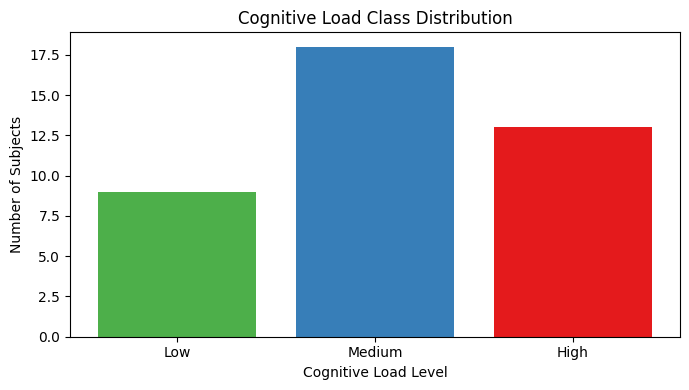

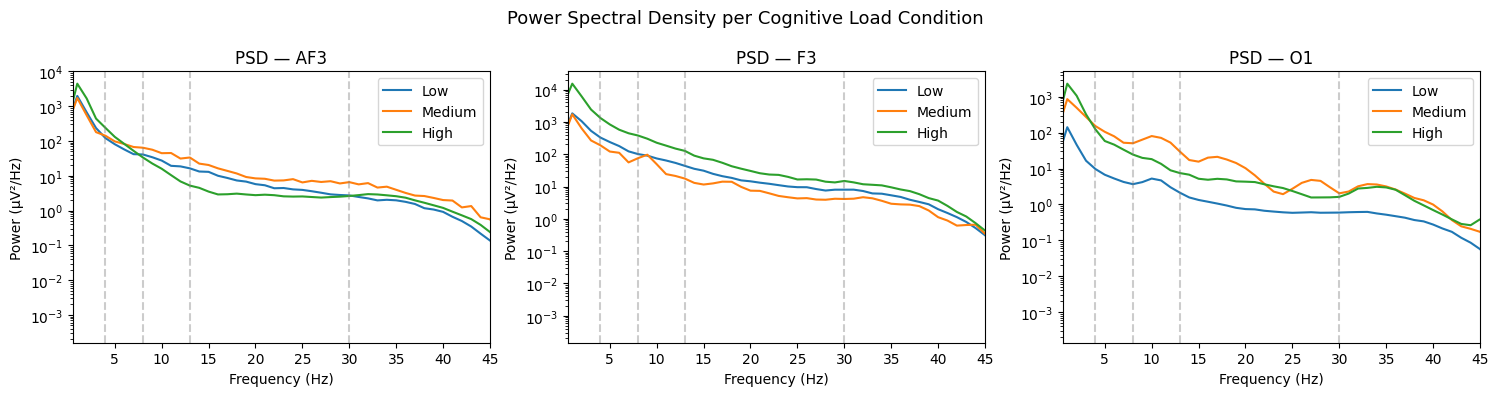

In [ ]:
label_names = {0: 'Low', 1: 'Medium', 2: 'High'}
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(7,4))
plt.bar([label_names[u] for u in unique], counts, color=['#4daf4a','#377eb8','#e41a1c'])
plt.title('Cognitive Load Class Distribution')
plt.xlabel('Cognitive Load Level')
plt.ylabel('Number of Subjects')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
CHANNELS_PLOT = ['AF3','F3','O1']
channel_indices = [CHANNELS.index(c) for c in CHANNELS_PLOT]
freq_bands = {'Delta':0.5,'Theta':4,'Alpha':8,'Beta':13,'Gamma':30,'End':45}

for ax, ch_idx, ch_name in zip(axes, channel_indices, CHANNELS_PLOT):
    for label in unique:
        subj_indices = np.where(y == label)[0]
        psds = []
        for si in subj_indices:
            eeg = dataset[ch_idx, :, si]
            freqs, psd = welch(eeg, fs=FS, nperseg=FS)
            psds.append(psd)
        mean_psd = np.mean(psds, axis=0)
        ax.semilogy(freqs, mean_psd, label=label_names[label])
    ax.set_title(f'PSD — {ch_name}')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (µV²/Hz)')
    ax.set_xlim([0.5, 45])
    ax.legend()
    for band_f in [4, 8, 13, 30]:
        ax.axvline(x=band_f, color='gray', linestyle='--', alpha=0.4)

plt.suptitle('Power Spectral Density per Cognitive Load Condition', fontsize=13)
plt.tight_layout()
plt.savefig('psd_per_condition.png', dpi=150)
plt.show()

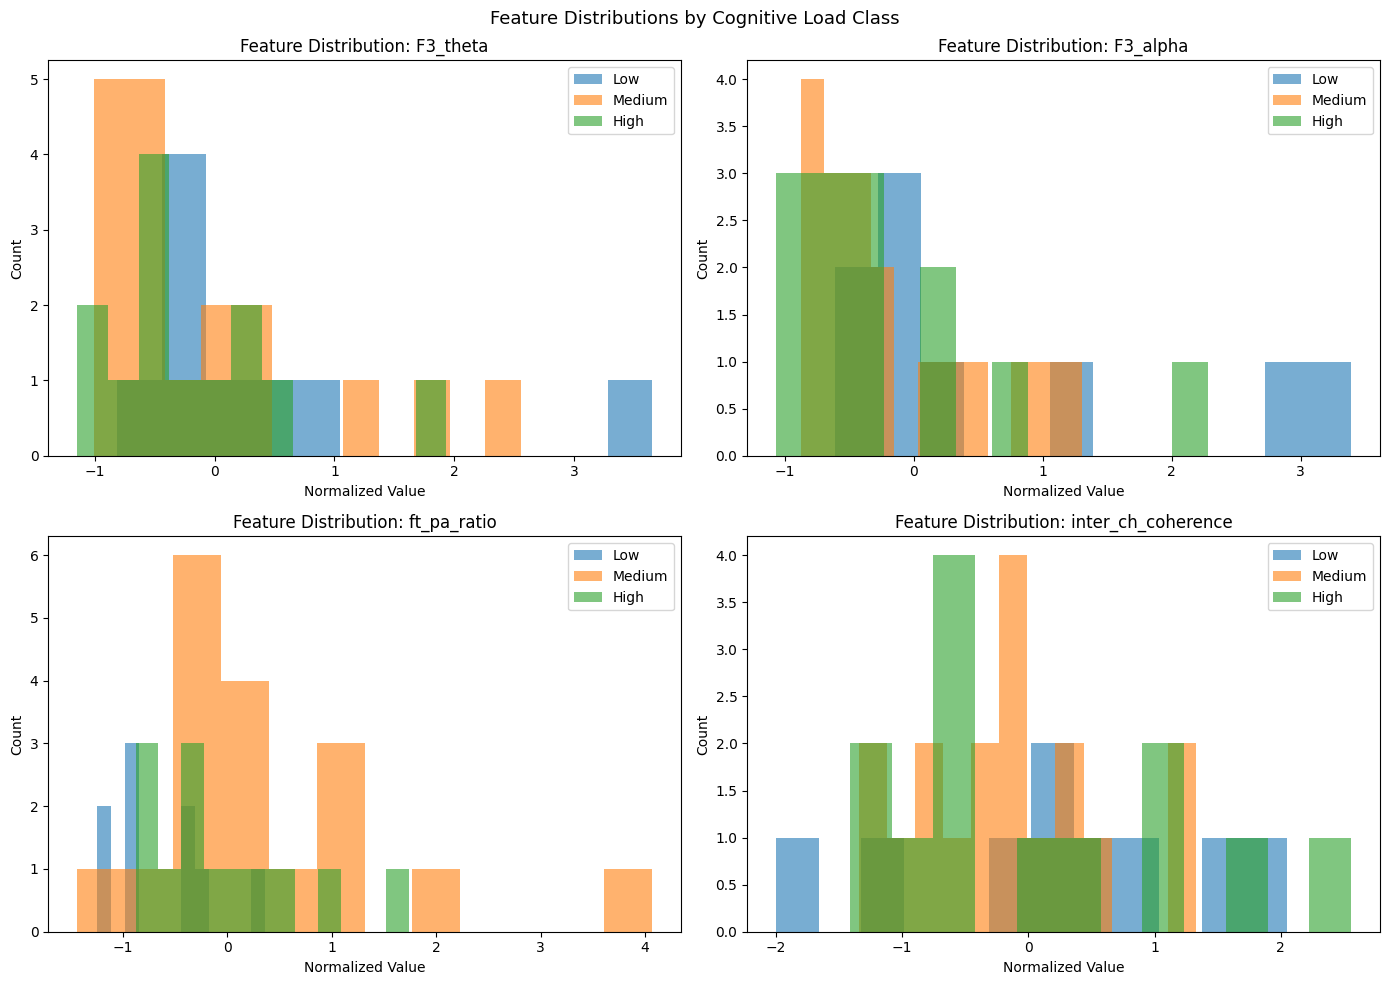

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

feature_names = []
for ch in CHANNELS:
    for band in ['delta','theta','alpha','beta','gamma']:
        feature_names.append(f"{ch}_{band}")
feature_names += ['frontal_theta','parietal_alpha','ft_pa_ratio','inter_ch_coherence']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_features = ['F3_theta', 'F3_alpha', 'ft_pa_ratio', 'inter_ch_coherence']

for ax, feat_name in zip(axes.flatten(), plot_features):
    feat_idx = feature_names.index(feat_name)
    for label in unique:
        vals = X_scaled[y == label, feat_idx]
        ax.hist(vals, alpha=0.6, bins=12, label=label_names[label])
    ax.set_title(f'Feature Distribution: {feat_name}')
    ax.set_xlabel('Normalized Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Feature Distributions by Cognitive Load Class', fontsize=13)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

In [ ]:
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    'SVM (RBF)':      SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'Random Forest':  RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':        XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                                    random_state=42, eval_metric='mlogloss', verbosity=0)
}

results = {}

for clf_name, clf in classifiers.items():
    fold_accs, fold_f1s = [], []
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_scaled, y)):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        fold_accs.append(accuracy_score(y_test, y_pred))
        fold_f1s.append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    results[clf_name] = {
        'acc_mean': np.mean(fold_accs),
        'acc_std':  np.std(fold_accs),
        'f1_mean':  np.mean(fold_f1s),
        'f1_std':   np.std(fold_f1s)
    }
    print(f"{clf_name}: Acc={np.mean(fold_accs):.4f}±{np.std(fold_accs):.4f}  Macro-F1={np.mean(fold_f1s):.4f}±{np.std(fold_f1s):.4f}")

print(f"\n{'='*60}")
print(f"{'Classifier':<20} {'Accuracy':>16} {'Macro-F1':>16}")
print(f"{'='*60}")
for clf_name, res in results.items():
    print(f"{clf_name:<20} {res['acc_mean']:.4f}±{res['acc_std']:.4f}  {res['f1_mean']:.4f}±{res['f1_std']:.4f}")
print(f"{'='*60}")

SVM (RBF): Acc=0.3750±0.2372  Macro-F1=0.3102±0.1746
Random Forest: Acc=0.3750±0.2500  Macro-F1=0.2893±0.2286
XGBoost: Acc=0.3500±0.2000  Macro-F1=0.3363±0.2201

Classifier                   Accuracy         Macro-F1
SVM (RBF)            0.3750±0.2372  0.3102±0.1746
Random Forest        0.3750±0.2500  0.2893±0.2286
XGBoost              0.3500±0.2000  0.3363±0.2201


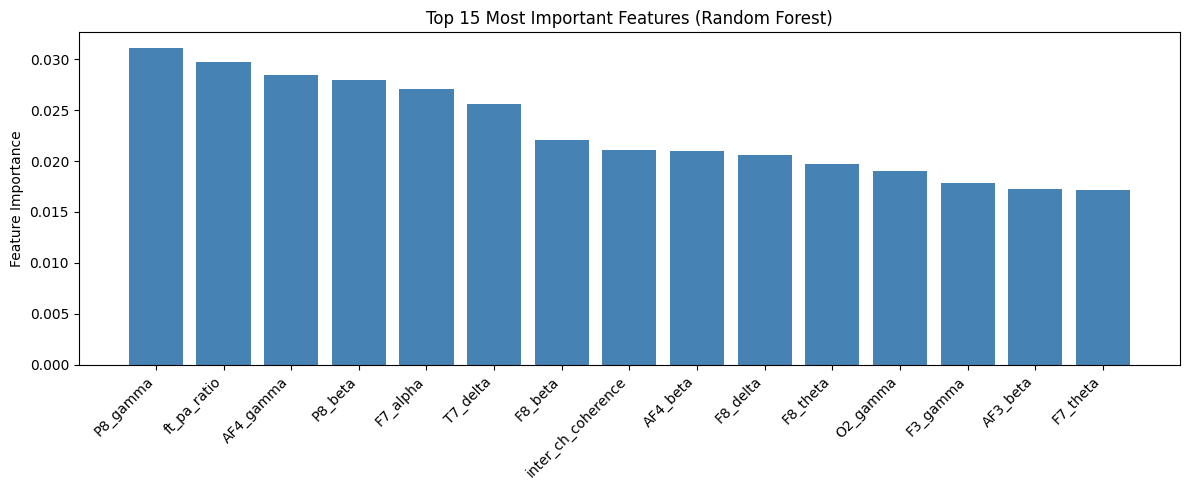


Top 15 Features and their neuroscience interpretation:
Feature                          Importance
---------------------------------------------
P8_gamma                             0.0311
ft_pa_ratio                          0.0298
AF4_gamma                            0.0285
P8_beta                              0.0279
F7_alpha                             0.0271
T7_delta                             0.0256
F8_beta                              0.0221
inter_ch_coherence                   0.0210
AF4_beta                             0.0210
F8_delta                             0.0206
F8_theta                             0.0197
O2_gamma                             0.0191
F3_gamma                             0.0178
AF3_beta                             0.0173
F7_theta                             0.0172


In [ ]:
best_clf = RandomForestClassifier(n_estimators=200, random_state=42)
best_clf.fit(X_scaled, y)

importances = best_clf.feature_importances_
top_k = 15
top_indices = np.argsort(importances)[::-1][:top_k]

plt.figure(figsize=(12, 5))
plt.bar(range(top_k), importances[top_indices], color='steelblue')
plt.xticks(range(top_k), [feature_names[i] for i in top_indices], rotation=45, ha='right')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.ylabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 15 Features and their neuroscience interpretation:")
print(f"{'Feature':<30} {'Importance':>12}")
print("-"*45)
for i in top_indices:
    print(f"{feature_names[i]:<30} {importances[i]:>12.4f}")

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         2
      Medium       0.50      0.75      0.60         4
        High       0.00      0.00      0.00         2

    accuracy                           0.38         8
   macro avg       0.17      0.25      0.20         8
weighted avg       0.25      0.38      0.30         8



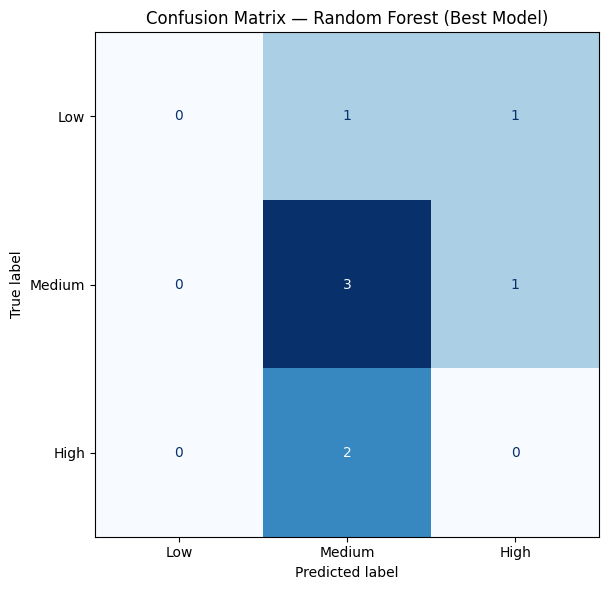

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

best_clf_final = RandomForestClassifier(n_estimators=200, random_state=42)
best_clf_final.fit(X_train, y_train)
y_pred_final = best_clf_final.predict(X_test)

print(classification_report(y_test, y_pred_final,
      target_names=[label_names[i] for i in sorted(label_names)]))

cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm, display_labels=[label_names[i] for i in sorted(label_names)]).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest (Best Model)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()